In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported")


Libraries imported


In [20]:
true_df = pd.read_csv('True.csv')
fake_df = pd.read_csv('Fake.csv')

true_df['label'] = 1
fake_df['label'] = 0  

df = pd.concat([true_df, fake_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"True news articles:  {len(true_df):,}")
print(f"Fake news articles:  {len(fake_df):,}")
print(f"Total dataset size:  {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nClass balance:")
print(df['label'].value_counts().rename({1:'Real', 0:'Fake'}))
df.head()


True news articles:  21,417
Fake news articles:  23,481
Total dataset size:  44,898
Columns: ['title', 'text', 'subject', 'date', 'label']

Class balance:
label
Fake    23481
Real    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


In [21]:
print("True news subjects:")
print(true_df['subject'].value_counts())
print()
print("Fake news subjects:")
print(fake_df['subject'].value_counts())


True news subjects:
subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64

Fake news subjects:
subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64


In [22]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

empty_text = (df['text'].str.strip() == '').sum()
empty_title = (df['title'].str.strip() == '').sum()
print(f"Empty text fields: {empty_text}")
print(f"Empty title fields: {empty_title}")


Missing values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64



Duplicate rows: 209
Empty text fields: 631
Empty title fields: 0


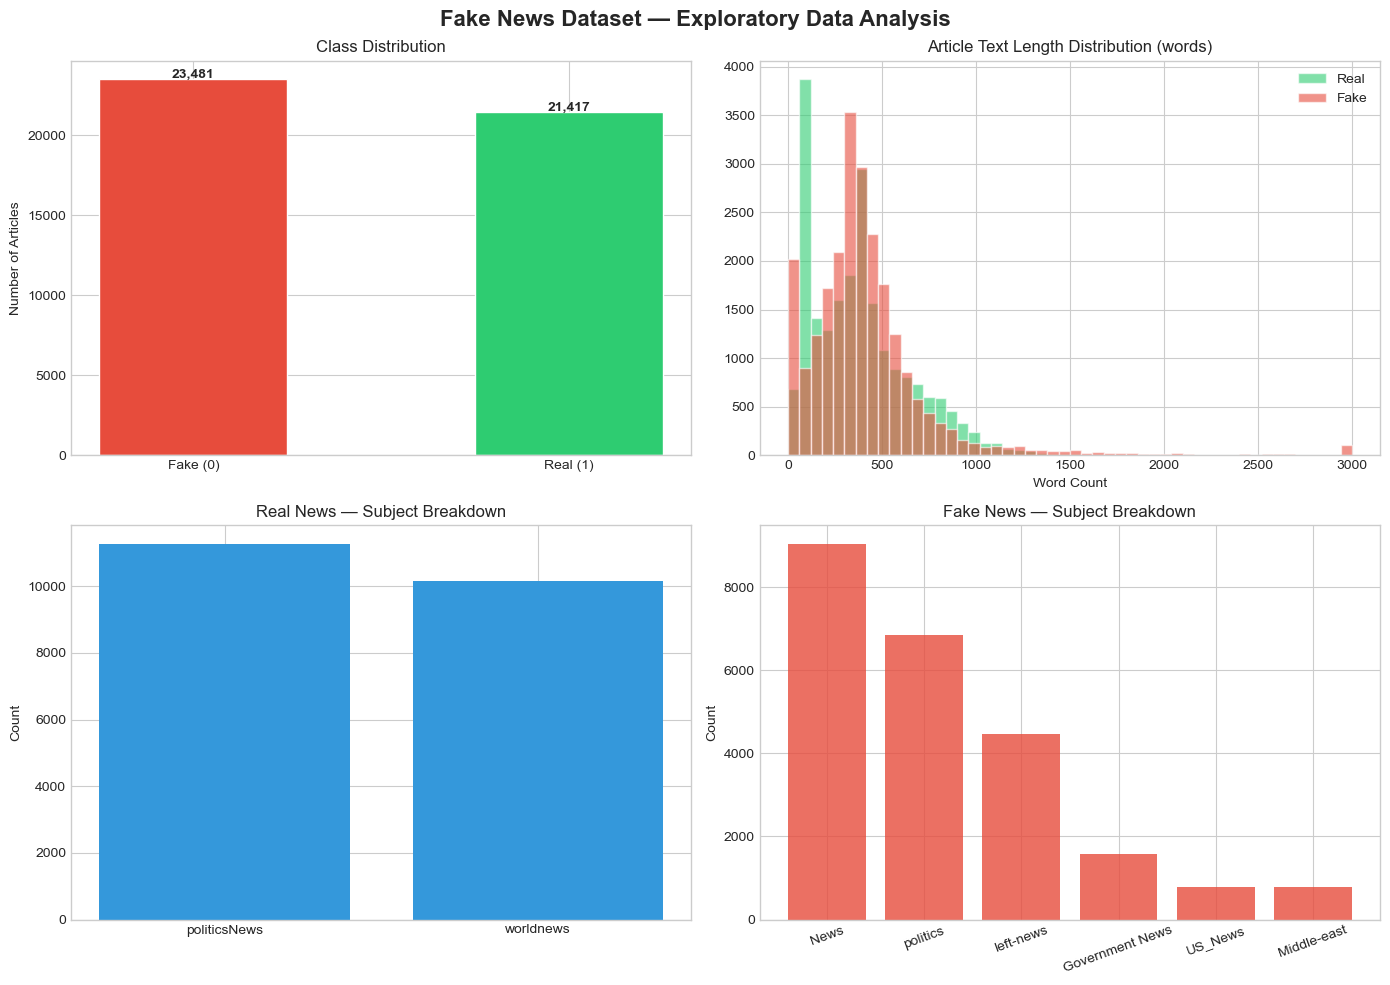

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fake News Dataset — Exploratory Data Analysis', fontsize=16, fontweight='bold')

counts = df['label'].value_counts()
axes[0,0].bar(['Fake (0)', 'Real (1)'], counts.values,
               color=['#e74c3c','#2ecc71'], edgecolor='white', width=0.5)
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Number of Articles')
for i, v in enumerate(counts.values):
    axes[0,0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

df['text_len'] = df['text'].str.split().str.len()
for label, color, name in [(1,'#2ecc71','Real'), (0,'#e74c3c','Fake')]:
    axes[0,1].hist(df[df['label']==label]['text_len'].clip(0,3000),
                   bins=50, alpha=0.6, label=name, color=color, edgecolor='white')
axes[0,1].set_title('Article Text Length Distribution (words)')
axes[0,1].set_xlabel('Word Count')
axes[0,1].legend()

real_sub = true_df['subject'].value_counts()
axes[1,0].bar(real_sub.index, real_sub.values, color='#3498db')
axes[1,0].set_title('Real News — Subject Breakdown')
axes[1,0].set_ylabel('Count')

fake_sub = fake_df['subject'].value_counts()
axes[1,1].bar(fake_sub.index, fake_sub.values, color='#e74c3c', alpha=0.8)
axes[1,1].set_title('Fake News — Subject Breakdown')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('fakenews_eda.png', dpi=120, bbox_inches='tight')
plt.show()


In [24]:
print("Average article length (words):")
print(f"  Real news: {df[df['label']==1]['text_len'].mean():.0f} words")
print(f"  Fake news: {df[df['label']==0]['text_len'].mean():.0f} words")


Average article length (words):
  Real news: 386 words
  Fake news: 423 words


In [25]:
def clean_text(text):
    """
    Clean raw news text:
    - Lowercase
    - Remove URLs
    - Remove punctuation
    - Remove extra whitespace
    Keep stopwords intentionally — TF-IDF handles weighting,
    and for fake news detection stylistic stopword patterns matter.
    """
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)    
    text = re.sub(r'<.*?>', '', text)                          
    text = re.sub(f'[{re.escape(string.punctuation)}]', ' ', text)  
    text = re.sub(r'\s+', ' ', text).strip()                 
    return text

df['content'] = df['title'] + ' ' + df['text']
df['content_clean'] = df['content'].apply(clean_text)

print("Text cleaned")
print(f"\nExample — original title: {df['title'].iloc[0][:80]}...")
print(f"Example — cleaned:        {df['content_clean'].iloc[0][:80]}...")


Text cleaned

Example — original title:  BREAKING: GOP Chairman Grassley Has Had Enough, DEMANDS Trump Jr. Testimony...
Example — cleaned:        breaking gop chairman grassley has had enough demands trump jr testimony donald ...


In [26]:
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2), sublinear_tf=True)

X = df['content_clean']
y = df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print(f"Training samples:  {X_train.shape[0]:,}")
print(f"Test samples:      {X_test.shape[0]:,}")
print(f"TF-IDF features:   {X_train.shape[1]:,} (unigrams + bigrams)")


Training samples:  35,918
Test samples:      8,980
TF-IDF features:   50,000 (unigrams + bigrams)


In [27]:
models = {
    'Naive Bayes':           MultinomialNB(),
    'Logistic Regression':   LogisticRegression(max_iter=1000, C=1.0),
    'Passive Aggressive':    PassiveAggressiveClassifier(max_iter=1000),
    'Linear SVM':            LinearSVC(max_iter=2000),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'accuracy':  accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall':    recall_score(y_test, preds),
        'f1':        f1_score(y_test, preds),
        'preds':     preds,
        'model':     model,
    }
    print(f"{name:25s} | Acc: {results[name]['accuracy']:.4f} | "
          f"P: {results[name]['precision']:.4f} | "
          f"R: {results[name]['recall']:.4f} | "
          f"F1: {results[name]['f1']:.4f}")


Naive Bayes               | Acc: 0.9580 | P: 0.9498 | R: 0.9629 | F1: 0.9563
Logistic Regression       | Acc: 0.9929 | P: 0.9914 | R: 0.9937 | F1: 0.9925
Passive Aggressive        | Acc: 0.9972 | P: 0.9972 | R: 0.9970 | F1: 0.9971
Linear SVM                | Acc: 0.9970 | P: 0.9967 | R: 0.9970 | F1: 0.9968


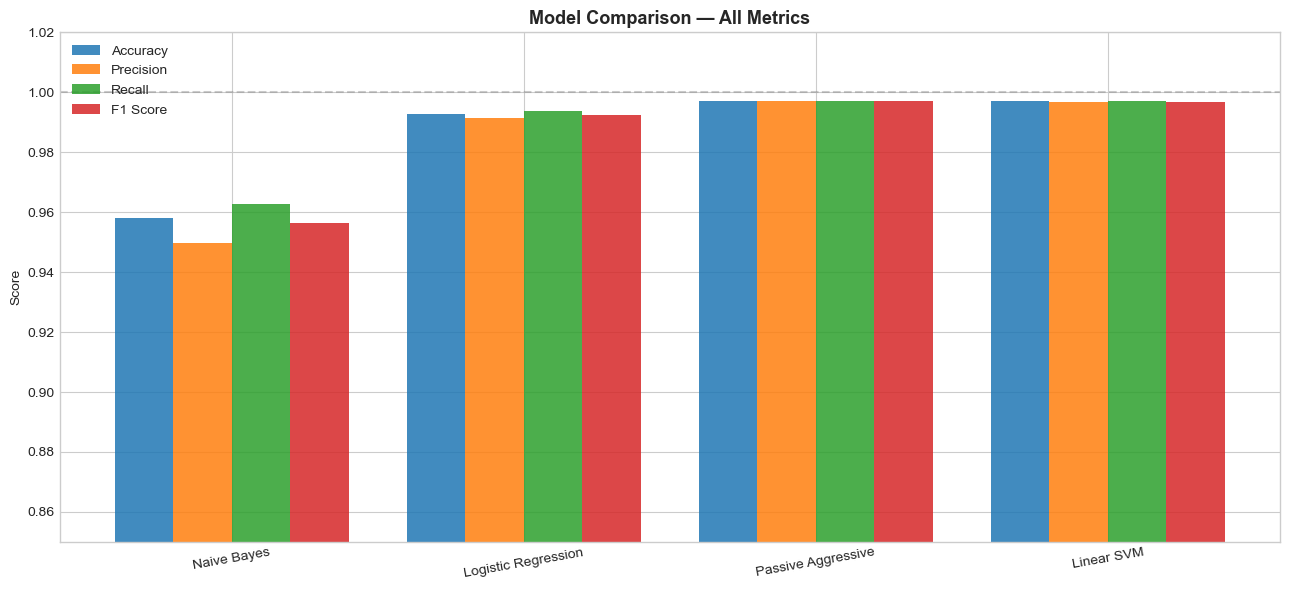


Best Model: Passive Aggressive  (F1: 0.9971)


In [28]:
metrics = ['accuracy','precision','recall','f1']
metric_labels = ['Accuracy','Precision','Recall','F1 Score']
names = list(results.keys())
x = np.arange(len(names))
w = 0.2

fig, ax = plt.subplots(figsize=(13, 6))
for i, (met, lab) in enumerate(zip(metrics, metric_labels)):
    vals = [results[n][met] for n in names]
    bars = ax.bar(x + i*w, vals, w, label=lab, alpha=0.85)

ax.set_xticks(x + w*1.5)
ax.set_xticklabels(names, rotation=10)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(1.0, color='grey', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('fakenews_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

best_name = max(results, key=lambda k: results[k]['f1'])
print(f"\nBest Model: {best_name}  (F1: {results[best_name]['f1']:.4f})")


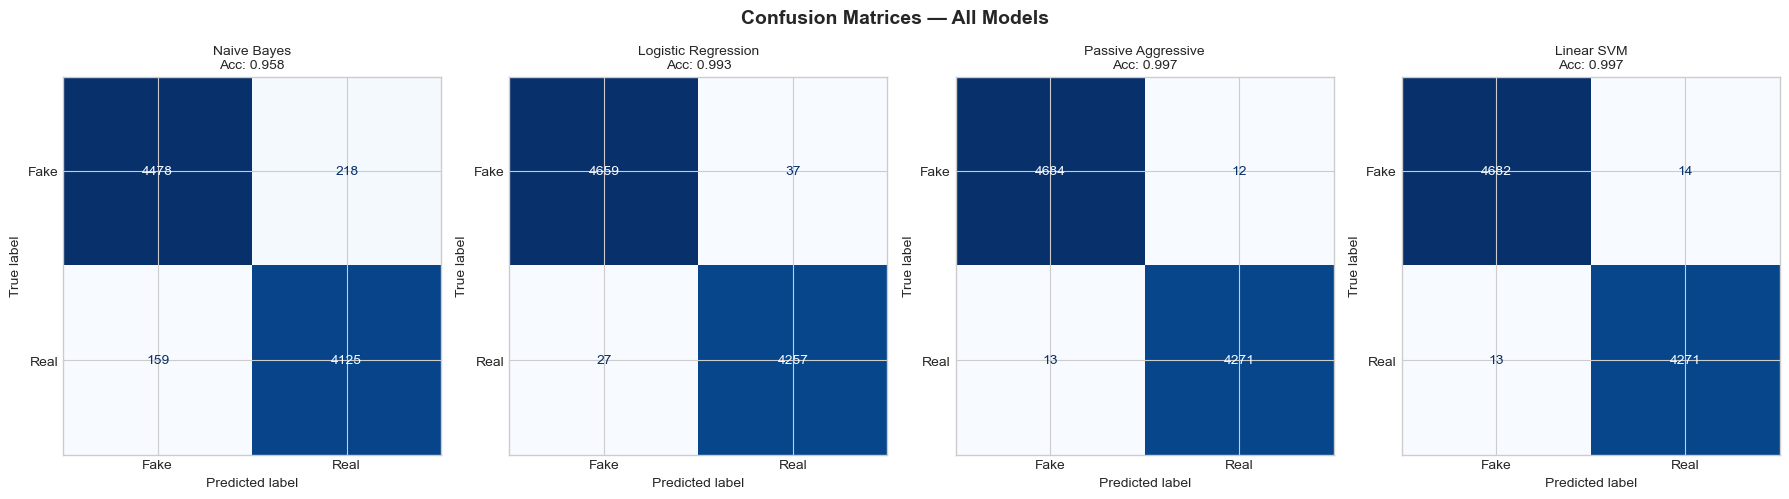

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Fake','Real'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAcc: {res['accuracy']:.3f}", fontsize=10)

plt.tight_layout()
plt.savefig('fakenews_confusion.png', dpi=120, bbox_inches='tight')
plt.show()


In [30]:
best = results[best_name]
print(f"Best Model: {best_name}")
print(f"Accuracy:  {best['accuracy']:.4f}")
print(f"Precision: {best['precision']:.4f}")
print(f"Recall:    {best['recall']:.4f}")
print(f"F1 Score:  {best['f1']:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, best['preds'], target_names=['Fake','Real']))


Best Model: Passive Aggressive
Accuracy:  0.9972
Precision: 0.9972
Recall:    0.9970
F1 Score:  0.9971

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



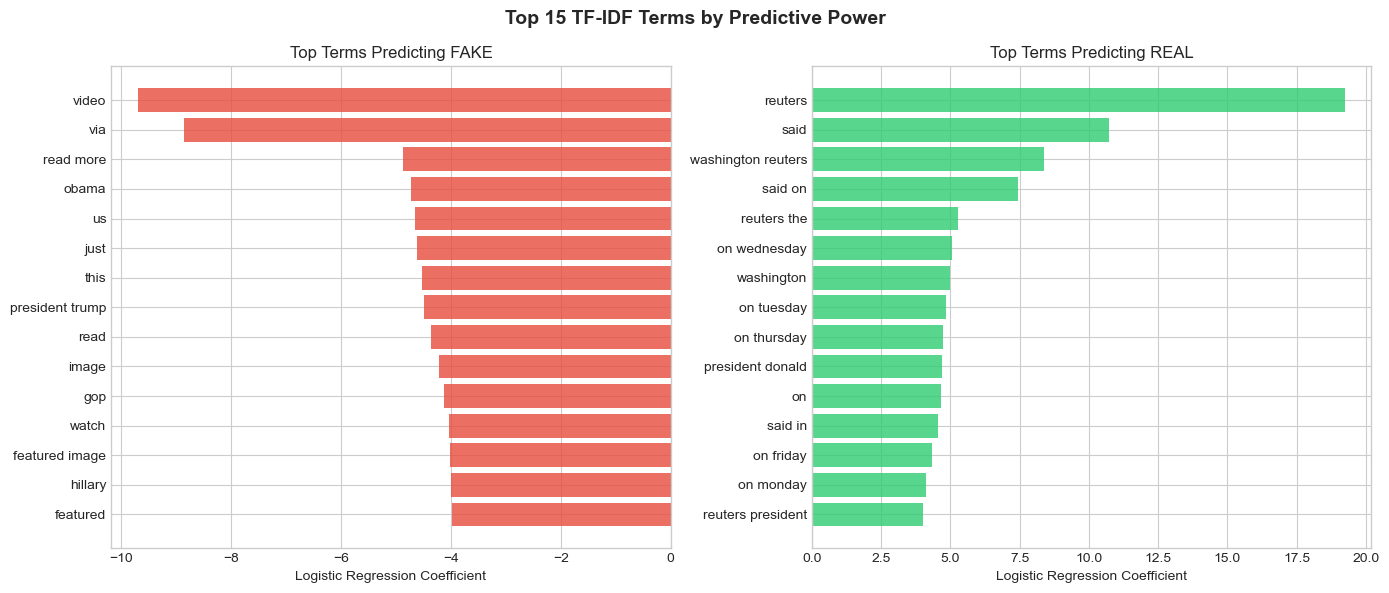

In [31]:
lr = results['Logistic Regression']['model']
feature_names = tfidf.get_feature_names_out()
coef = lr.coef_[0]

top_fake_idx = np.argsort(coef)[:15]      
top_real_idx = np.argsort(coef)[-15:][::-1]  

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Top 15 TF-IDF Terms by Predictive Power', fontsize=14, fontweight='bold')

axes[0].barh(feature_names[top_fake_idx][::-1],
             coef[top_fake_idx][::-1], color='#e74c3c', alpha=0.8)
axes[0].set_title('Top Terms Predicting FAKE')
axes[0].set_xlabel('Logistic Regression Coefficient')

axes[1].barh(feature_names[top_real_idx][::-1],
             coef[top_real_idx][::-1], color='#2ecc71', alpha=0.8)
axes[1].set_title('Top Terms Predicting REAL')
axes[1].set_xlabel('Logistic Regression Coefficient')

plt.tight_layout()
plt.savefig('fakenews_features.png', dpi=120, bbox_inches='tight')
plt.show()


In [32]:
best_model = results[best_name]['model']

def predict_news(text):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    pred = best_model.predict(vec)[0]
    label = 'REAL' if pred == 1 else 'FAKE'
    return label

test_headlines = [
    "Reuters: Federal Reserve raises interest rates by 0.25 percent",
    "SHOCKING: Obama secretly faked the moon landing with George Soros",
    "Pentagon confirms new defence budget approved by Congress",
    "Scientists discover that drinking bleach cures all diseases - SHARE NOW",
]

print(f"using model: {best_name}\n")
for headline in test_headlines:
    result = predict_news(headline)
    print(f"{result} | {headline[:70]}")


using model: Passive Aggressive

REAL | Reuters: Federal Reserve raises interest rates by 0.25 percent
FAKE | SHOCKING: Obama secretly faked the moon landing with George Soros
FAKE | Pentagon confirms new defence budget approved by Congress
FAKE | Scientists discover that drinking bleach cures all diseases - SHARE NO
